In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('isimler.txt', 'r', encoding='utf-8').read().splitlines()
words[:8]

['adem', 'neslihan', 'akın', 'dilek', 'çiğdem', 'can', 'abdullah', 'habip']

In [3]:
len(words)

30000

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'r', 18: 's', 19: 't', 20: 'u', 21: 'v', 22: 'y', 23: 'z', 24: 'â', 25: 'ç', 26: 'ö', 27: 'ü', 28: 'ğ', 29: 'ı', 30: 'ş', 31: '̇', 0: '.'}


In [5]:
# build the dataset

def build_dataset(words) :
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), ' -- >', itos[ix])
            context = context [1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([153000, 3]) torch.Size([153000])
torch.Size([19138, 3]) torch.Size([19138])
torch.Size([19139, 3]) torch.Size([19139])


In [6]:
n_embed = 10
n_hidden = 200
vocab_size = 32
block_size = 3

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embed), generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden), generator=g) * (5/3)/((n_embed * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [7]:
import torch.nn.functional as F

lossi = []
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
max_steps = 100000
batch_size = 32

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # (batch_size, block_size, n_embed)
    embcat = emb.view(emb.shape[0], -1) # (batch_size, block_size*n_embed)

    hpreact = embcat @ W1 + b1

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact) # (batch_size, n_hidden)
    logits = h @ W2 + b2 # (batch_size, vocab_size)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 1000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 100000: 3.4540
   1000/ 100000: 2.0537
   2000/ 100000: 1.9796
   3000/ 100000: 1.8414
   4000/ 100000: 1.1452
   5000/ 100000: 1.3282
   6000/ 100000: 1.2919
   7000/ 100000: 0.9067
   8000/ 100000: 1.1560
   9000/ 100000: 1.3805
  10000/ 100000: 1.3027
  11000/ 100000: 1.4186
  12000/ 100000: 1.1340
  13000/ 100000: 1.0638
  14000/ 100000: 1.2923
  15000/ 100000: 1.0712
  16000/ 100000: 1.2087
  17000/ 100000: 0.9184
  18000/ 100000: 1.1145
  19000/ 100000: 1.0495
  20000/ 100000: 1.3567
  21000/ 100000: 0.8145
  22000/ 100000: 0.8956
  23000/ 100000: 1.5858
  24000/ 100000: 1.4414
  25000/ 100000: 1.1179
  26000/ 100000: 1.1571
  27000/ 100000: 0.9241
  28000/ 100000: 1.1483
  29000/ 100000: 1.0920
  30000/ 100000: 1.2934
  31000/ 100000: 0.9516
  32000/ 100000: 1.2185
  33000/ 100000: 0.9816
  34000/ 100000: 1.1489
  35000/ 100000: 0.6928
  36000/ 100000: 1.1549
  37000/ 100000: 0.9627
  38000/ 100000: 1.0577
  39000/ 100000: 1.2590
  40000/ 100000: 1.2386
  41000/ 100000:

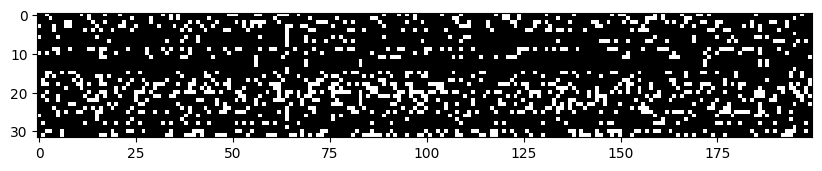

In [8]:
plt.figure(figsize=(10, 6))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([960., 298., 202., 175., 130., 115., 117.,  98.,  93.,  91.,  81.,
         42.,  54.,  62.,  71.,  53.,  51.,  55.,  57.,  56.,  65.,  58.,
         73.,  65.,  59.,  53.,  46.,  54.,  59.,  44.,  65.,  55.,  56.,
         56.,  61.,  59.,  53.,  88.,  93.,  68.,  73.,  91.,  95., 102.,
        136., 128., 155., 221., 310., 998.]),
 array([-9.99999642e-01, -9.59999659e-01, -9.19999676e-01, -8.79999692e-01,
        -8.39999709e-01, -7.99999726e-01, -7.59999743e-01, -7.19999759e-01,
        -6.79999776e-01, -6.39999793e-01, -5.99999809e-01, -5.59999826e-01,
        -5.19999843e-01, -4.79999859e-01, -4.39999876e-01, -3.99999893e-01,
        -3.59999909e-01, -3.19999926e-01, -2.79999943e-01, -2.39999959e-01,
        -1.99999976e-01, -1.59999993e-01, -1.20000010e-01, -8.00000262e-02,
        -4.00000429e-02, -5.96046448e-08,  3.99999237e-02,  7.99999070e-02,
         1.19999890e-01,  1.59999874e-01,  1.99999857e-01,  2.39999840e-01,
         2.79999824e-01,  3.19999807e-01,  3.59999

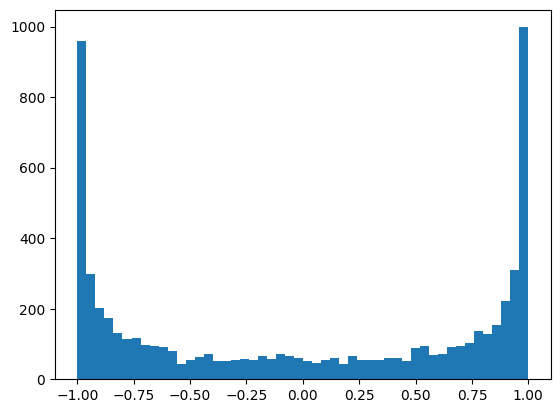

In [9]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   1.,   3.,   1.,   2.,   7.,   8.,   9.,  16.,  23.,  31.,
         39.,  54.,  77.,  88., 116., 128., 168., 218., 257., 311., 338.,
        405., 348., 445., 415., 392., 394., 373., 317., 289., 252., 198.,
        151., 136., 100.,  70.,  69.,  34.,  30.,  17.,  15.,  22.,  11.,
          3.,   2.,   9.,   3.,   2.,   2.]),
 array([-7.76877499, -7.46043122, -7.15208746, -6.8437437 , -6.53539993,
        -6.22705617, -5.91871241, -5.61036864, -5.30202488, -4.99368112,
        -4.68533735, -4.37699359, -4.06864983, -3.76030606, -3.4519623 ,
        -3.14361854, -2.83527477, -2.52693101, -2.21858725, -1.91024348,
        -1.60189972, -1.29355596, -0.98521219, -0.67686843, -0.36852467,
        -0.0601809 ,  0.24816286,  0.55650662,  0.86485039,  1.17319415,
         1.48153791,  1.78988168,  2.09822544,  2.4065692 ,  2.71491297,
         3.02325673,  3.33160049,  3.63994426,  3.94828802,  4.25663178,
         4.56497555,  4.87331931,  5.18166307,  5.49000684,  5.7983506 ,
 

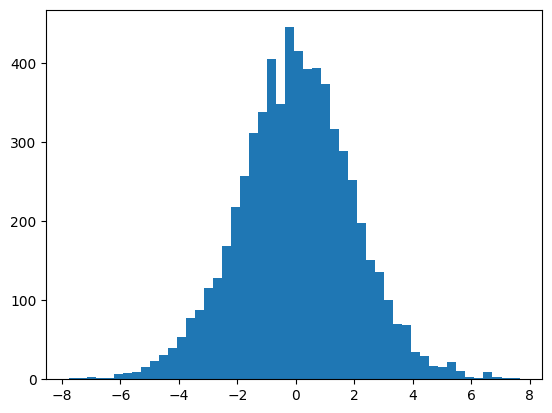

In [10]:
plt.hist(hpreact.view(-1).tolist(), 50)

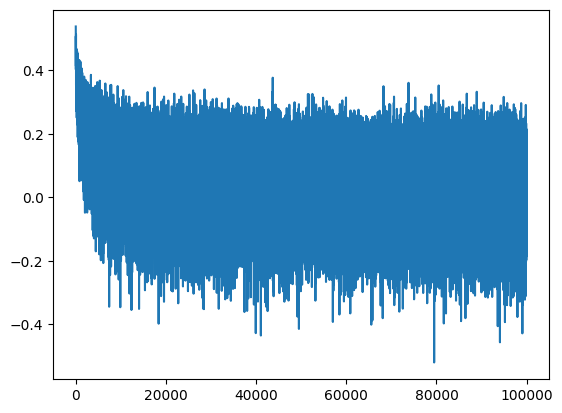

In [11]:
plt.plot(lossi)

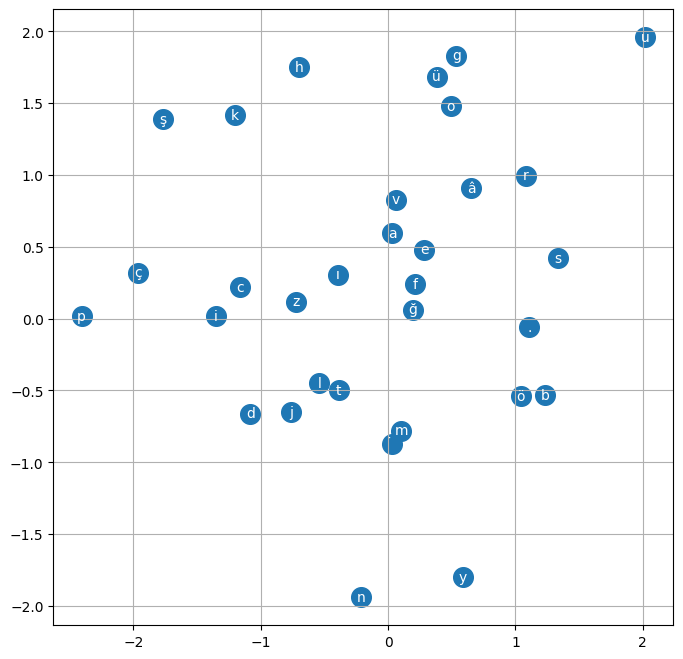

In [12]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [13]:
@torch.no_grad()
def split_loss(split):
    x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch. tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.644239068031311
val 1.6940678358078003


In [14]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch. tensor([context] )] # (1,block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context [1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

cuhmahmettilli̇mmeḋmehmeydel.
yusufgtuluhtibel.
reşat.
yusufgitalalevet.
yıldız.
yeşdemetlcayi̇m.
raziyemrö.
yusufgtuşadimel̇nsinhjraziydemetrcan.
yecegümuyabdullahhetkıldırvubtazekiyem.
aysunazmilalsızımeryemduğadçan.
yusuf.
ç̇brahim.
kadır.
şadimeygüneşedamdamıkmet.
uğunç.
yahyticelraziyemre.
aydın.
yalçın.
süleymanazmi.
akınmazandum.
